# [실습] 네이버 영화 리뷰 감성 분류 Fine-Tuning

앞서 뉴스 주제 분류(KLUE-YNAT, 7개 클래스)를 해봤습니다.  
이번에는 **네이버 영화 리뷰 감성 분류(NSMC, 2개 클래스)** 를 직접 구현해봅니다.

| 항목 | 데모에서 한 것 | 이번 실습 |
|------|----------------|----------|
| 데이터셋 | `klue/ynat` (뉴스 주제) | `nsmc` (영화 리뷰 감성) |
| 모델 | `klue/bert-base` | `klue/bert-base` (동일) |
| 분류 수 | 7개 (IT과학, 경제, …) | 2개 (긍정/부정) |
| 텍스트 컬럼 | `title` | `document` |
| 레이블 컬럼 | `label` (0~6) | `label` (0 또는 1) |

> **핵심 포인트**: 코드 구조는 데모와 거의 동일합니다.  
> "어디를 바꿔야 하는지" 찾는 것이 이번 실습의 목표입니다.

---
## 1단계: 패키지 설치

- 오류 방지를 위해 datasets만 업데이트 합니다.

In [1]:
!pip install -q --upgrade datasets

---
## 2단계: 라이브러리 임포트 및 GPU 확인

아래 라이브러리들을 임포트하세요:

- `torch` — GPU 사용 여부 확인
- `numpy` — 배열 연산
- `datasets`의 `load_dataset` — 데이터셋 불러오기
- `transformers`에서:
  - `AutoTokenizer` — 토크나이저
  - `AutoModelForSequenceClassification` — 분류 모델
  - `TrainingArguments` — 학습 설정
  - `Trainer` — 학습 실행
  - `EarlyStoppingCallback` — 조기 종료
- `sklearn.metrics`에서 `accuracy_score`, `f1_score`, `classification_report`, `confusion_matrix`
- `matplotlib.pyplot`, `seaborn` — 시각화

임포트 후, `torch.device`로 GPU가 사용 가능한지 확인하고 출력하세요.

In [2]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


---
## 3단계: 데이터셋 로드 및 탐색

**NSMC** 데이터셋을 GitHub에서 TSV 파일로 직접 불러옵니다.

In [ ]:
dataset = load_dataset("csv", data_files={
    "train": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    "test": "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
}, delimiter="\t")

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 150000
    })
    test: Dataset({
        features: ['id', 'document', 'label'],
        num_rows: 50000
    })
})

컬럼: ['id', 'document', 'label']

샘플 데이터:
  [0] {'id': 9976970, 'document': '아 더빙.. 진짜 짜증나네요 목소리', 'label': 0}
  [1] {'id': 3819312, 'document': '흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나', 'label': 1}
  [2] {'id': 10265843, 'document': '너무재밓었다그래서보는것을추천한다', 'label': 0}


불러온 뒤 다음을 확인하세요:
- 전체 구조 (`print(dataset)`) — train/test로 나뉘어 있습니다
- 컬럼 이름 확인 — `id`, `document`, `label` 3개 컬럼이 있습니다
- 샘플 데이터 3개 정도 출력

> **참고**: NSMC의 레이블은 `0 = 부정`, `1 = 긍정`입니다.

In [ ]:
print(dataset)
print(f"\n컬럼: {dataset['train'].column_names}")
print(f"\n샘플 데이터:")
for i in range(3):
    print(f"  [{i}] {dataset['train'][i]}")

---
## 4단계: 레이블 매핑 및 데이터 분할

### 레이블 매핑
NSMC는 이진 분류이므로:
- `num_labels = 2`
- `id2label = {0: "부정", 1: "긍정"}`
- `label2id = {"부정": 0, "긍정": 1}`

### 데이터 분할
NSMC 원본은 train 15만 건, test 5만 건으로 양이 많습니다.  
실습에서는 **소규모로 추출**하여 빠르게 학습합니다.

- **train**: 12,000개를 셔플 후 추출 → `train_test_split()`으로 **10,000 / 2,000** 분할
- **test**: 2,000개를 셔플 후 추출

최종 데이터 구성:

| 분할 | 건수 |
|------|------|
| Train | 10,000 |
| Validation | 2,000 |
| Test | 2,000 |

각 분할의 레이블 분포도 확인하세요 (`Counter` 사용).

> **주의**: NSMC의 `document` 컬럼에는 간혹 `None` 값이 있습니다.  
> 필요시 `dataset.filter(lambda x: x["document"] is not None)`으로 제거하세요.

In [4]:
from collections import Counter

num_labels = 2
id2label = {0: "부정", 1: "긍정"}
label2id = {"부정": 0, "긍정": 1}

# train에서 10000개 추출 후 train/validation 분할
train_subset = dataset["train"].shuffle(seed=42).select(range(12000))
split = train_subset.train_test_split(test_size=2000, seed=42)
train_dataset = split["train"]  # 10000개
val_dataset = split["test"]     # 2000개

# test에서 2000개 추출
test_dataset = dataset["test"].shuffle(seed=42).select(range(2000))

print(Counter([data['label'] for data in train_dataset]))
print(Counter([data['label'] for data in test_dataset]))
print(Counter([data['label'] for data in val_dataset]))
print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Counter({1: 5064, 0: 4936})
Counter({0: 1033, 1: 967})
Counter({0: 1007, 1: 993})
Train: 10000
Validation: 2000
Test: 2000


---
## 5단계: 토크나이저 로드 및 토큰화

### 토크나이저 로드
모델 이름은 데모와 동일하게 `"klue/bert-base"`를 사용합니다.  
`AutoTokenizer.from_pretrained()`로 불러오세요.

### 토큰화 함수 작성
토큰화 함수를 만드세요. 핵심 설정:
- **텍스트 컬럼**: NSMC는 `"document"` 컬럼에 텍스트가 있습니다 (데모의 `"title"`과 다릅니다!)
- `padding="max_length"` — 고정 길이로 패딩
- `truncation=True` — 긴 텍스트 잘라내기
- `max_length=128`

### 토큰화 적용
- `train_dataset`, `val_dataset`, `test_dataset` 모두에 `.map(tokenize_fn, batched=True)` 적용
- `.set_format("torch", columns=["input_ids", "attention_mask", "label"])`로 PyTorch 형식 설정
- 샘플 토큰을 디코딩해서 잘 변환되었는지 확인

In [5]:
MODEL_NAME = "klue/bert-base"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(
        examples['document'],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_dataset = train_dataset.map(tokenize_fn, batched=True)
val_dataset = val_dataset.map(tokenize_fn, batched=True)
test_dataset = test_dataset.map(tokenize_fn, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print(f"토큰화 완료 (max_length={MAX_LENGTH})")
print(f"샘플 토큰: {tokenizer.decode(train_dataset[0]['input_ids'][:30])}")

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

토큰화 완료 (max_length=128)
샘플 토큰: [CLS] 뭐 이런게 ㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


---
## 6단계: 모델 로드

`AutoModelForSequenceClassification.from_pretrained()`로 모델을 불러오세요.

설정할 인자:
- `model_name`: `"klue/bert-base"`
- `num_labels`: 이진 분류이므로 2
- `id2label`, `label2id`: 4단계에서 만든 매핑

불러온 뒤:
- `.to(device)`로 GPU에 올리세요
- 전체 파라미터 수를 출력하세요

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)
model.to(device)
print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


모델 파라미터 수: 110,618,882


---
## 7단계: 학습 설정 및 Fine-Tuning

### 평가 함수
`compute_metrics` 함수를 작성하세요:
- 입력: `eval_pred` (logits, labels 튜플)
- logits에서 `np.argmax`로 예측값 추출
- `accuracy_score`와 `f1_score(average="weighted")`를 계산해서 딕셔너리로 반환

### TrainingArguments 설정

| 설정 | 값 | 설명 |
|------|----|------|
| `output_dir` | `"./results"` | 결과 저장 경로 |
| `num_train_epochs` | 3 | |
| `per_device_train_batch_size` | 32 | |
| `per_device_eval_batch_size` | 64 | |
| `learning_rate` | 2e-5 | |
| `weight_decay` | 0.01 | |
| `warmup_ratio` | 0.1 | |
| `eval_strategy` | `"epoch"` | 매 에폭마다 평가 |
| `save_strategy` | `"epoch"` | 매 에폭마다 저장 |
| `load_best_model_at_end` | `True` | |
| `metric_for_best_model` | `"f1"` | |
| `fp16` | GPU 사용 시 True | |
| `report_to` | `"none"` | wandb 등 비활성화 |

### Trainer 생성 및 학습
- `Trainer`에 모델, 학습 인자, train/eval 데이터셋, 평가 함수, EarlyStoppingCallback을 넣으세요
- `trainer.train()`으로 학습을 실행하세요

> **참고**: 10,000건 기준으로 Colab T4에서 에폭당 약 1~2분 걸립니다.

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("학습 시작...")
train_result = trainer.train()
print(f"\n학습 완료!")
print(f"  Total steps: {train_result.global_step}")
print(f"  Training loss: {train_result.training_loss:.4f}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


학습 시작...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.343828,0.325593,0.861500,0.861312
2,0.242287,0.335849,0.877500,0.877497
3,0.142570,0.368750,0.879000,0.878996


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


학습 완료!
  Total steps: 939
  Training loss: 0.2630


---
## 8단계: 학습 곡선 시각화

`trainer.state.log_history`에서 학습 로그를 꺼내서 그래프를 그려보세요.

그려야 할 그래프 3개:
1. **Training Loss** — step별 학습 손실 (x: step, y: loss)
2. **Validation Loss** — epoch별 검증 손실 (x: epoch, y: eval_loss)
3. **Validation Metrics** — epoch별 accuracy와 f1 (x: epoch, y: score)

`plt.subplots(1, 3, figsize=(18, 5))`로 한 줄에 3개 그래프를 배치하면 보기 좋습니다.

> **힌트**: `log_history`는 딕셔너리 리스트입니다.  
> `"loss"` 키가 있으면 학습 로그, `"eval_loss"` 키가 있으면 평가 로그입니다.

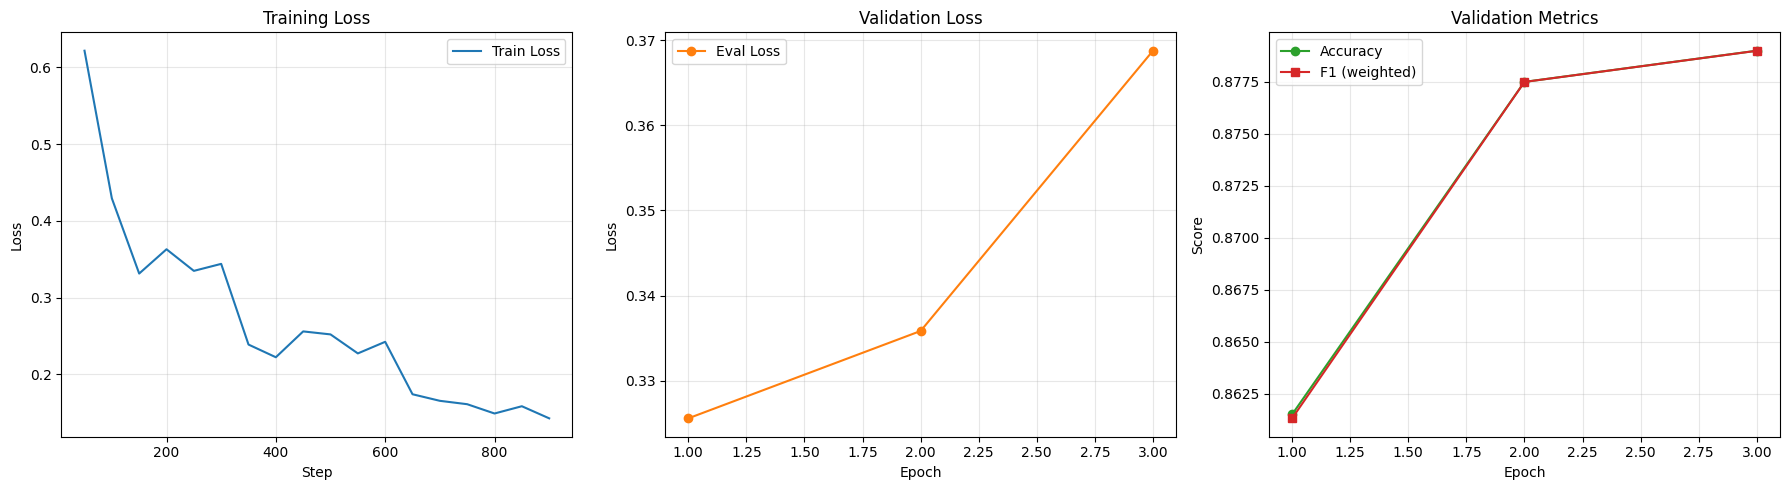

In [8]:
log_history = trainer.state.log_history

train_losses = [(x["step"], x["loss"]) for x in log_history if "loss" in x and "eval_loss" not in x]
eval_entries = [x for x in log_history if "eval_loss" in x]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training Loss
steps, losses = zip(*train_losses)
axes[0].plot(steps, losses, label="Train Loss", color="tab:blue")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Eval Loss
eval_epochs = [x["epoch"] for x in eval_entries]
eval_losses = [x["eval_loss"] for x in eval_entries]
axes[1].plot(eval_epochs, eval_losses, marker="o", label="Eval Loss", color="tab:orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Validation Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Eval Metrics
eval_acc = [x["eval_accuracy"] for x in eval_entries]
eval_f1 = [x["eval_f1"] for x in eval_entries]
axes[2].plot(eval_epochs, eval_acc, marker="o", label="Accuracy", color="tab:green")
axes[2].plot(eval_epochs, eval_f1, marker="s", label="F1 (weighted)", color="tab:red")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Score")
axes[2].set_title("Validation Metrics")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9단계: 테스트셋 평가

`trainer.evaluate(test_dataset)`으로 테스트셋 성능을 측정하세요.

출력할 지표:
- Loss
- Accuracy
- F1 Score

> **기대 성능**: BERT-base로 NSMC를 학습하면 보통 **accuracy 88~90%** 정도 나옵니다.

In [9]:
test_results = trainer.evaluate(test_dataset)
print("=== 테스트셋 결과 ===")
print(f"  Loss:     {test_results['eval_loss']:.4f}")
print(f"  Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"  F1:       {test_results['eval_f1']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.142570,0.404074,3,0.869000,0.869018


=== 테스트셋 결과 ===
  Loss:     0.4041
  Accuracy: 0.8690
  F1:       0.8690


---
## 10단계: Classification Report & Confusion Matrix

### Classification Report
- `trainer.predict(test_dataset)`으로 전체 예측 수행
- `np.argmax(predictions.predictions, axis=-1)`로 예측 레이블 추출
- `classification_report()`로 precision, recall, f1을 클래스별로 출력
- `target_names`에 `["부정", "긍정"]`을 넣으세요

### Confusion Matrix
- `confusion_matrix()`로 혼동 행렬 계산
- `seaborn.heatmap()`으로 시각화 (annot=True, fmt="d", cmap="Blues")
- x축/y축 레이블에 "부정", "긍정"을 넣으세요

              precision    recall  f1-score   support

         bad       0.88      0.87      0.87      1033
        good       0.86      0.87      0.87       967

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



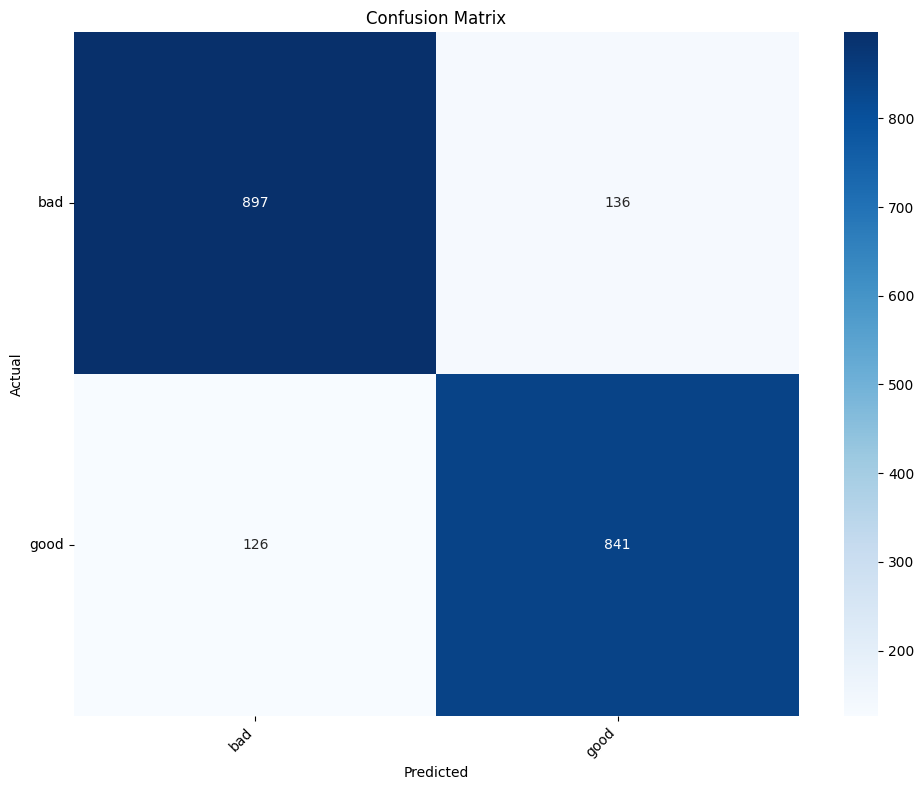

In [11]:
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

target_names = ['bad', 'good']
print(classification_report(labels, preds, target_names=target_names))

# Confusion Matrix 시각화
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 11단계: 추론 테스트

학습된 모델로 직접 영화 리뷰 문장을 넣어서 감성을 예측해보세요.

### 추론 함수 작성
텍스트를 받아서 긍정/부정과 확률을 반환하는 함수를 만드세요:
1. `tokenizer()`로 텍스트를 토큰화 (`return_tensors="pt"`, `truncation=True`, `padding=True`)
2. 토큰을 GPU로 이동
3. `model.eval()` + `torch.no_grad()` 안에서 `model(**inputs)` 실행
4. `torch.softmax()`로 확률 변환
5. `argmax`로 예측 클래스, 해당 확률을 반환

### 테스트 문장 예시
리뷰들을 직접 넣어서 결과를 확인하거나 테스트셋에서 모델이 틀린 데이터들을 확인해 보세요.

In [12]:
def predict_topic(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)[0]
    pred_id = probs.argmax().item()
    confidence = probs[pred_id].item()

    return id2label[pred_id], confidence

test_texts = [
    "삼성전자, 반도체 사업 실적 개선 기대감에 주가 상승",
    "손흥민, 프리미어리그 시즌 최다 골 기록 경신",
    "정부, 부동산 규제 완화 방안 발표 예정",
    "애플, 새로운 AI 기능 탑재한 아이폰 공개",
]

print("=== 추론 테스트 ===")
for text in test_texts:
    topic, conf = predict_topic(text)
    print(f"\n입력: {text}")
    print(f"예측: {topic} (확률: {conf:.2%})")

=== 추론 테스트 ===

입력: 삼성전자, 반도체 사업 실적 개선 기대감에 주가 상승
예측: 긍정 (확률: 74.08%)

입력: 손흥민, 프리미어리그 시즌 최다 골 기록 경신
예측: 긍정 (확률: 68.62%)

입력: 정부, 부동산 규제 완화 방안 발표 예정
예측: 긍정 (확률: 53.94%)

입력: 애플, 새로운 AI 기능 탑재한 아이폰 공개
예측: 긍정 (확률: 64.02%)


---
## 도전 과제 (선택)

시간이 남으면 아래를 시도해보세요:

1. **하이퍼파라미터 실험**: `learning_rate`를 `5e-5`, `1e-5`로 바꿔보고 성능 차이를 비교해보세요
2. **다른 모델 사용**: `"klue/bert-base"` 대신 huggingface의 다른 모델을 사용해 학습해 보세요 — 코드에서 모델 이름만 바꾸면 됩니다
3. **오분류 분석**: 모델이 틀린 샘플들을 뽑아서 "왜 틀렸을까?" 살펴보세요